In [1]:
#Notebook Setup/Load Data

import sys, os
from pathlib import Path
sys.path.append(str(Path('../src').resolve()))
os.chdir('..') 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from data_pipe import load_region
from data_preprocessing import build_clean_hourly_index

plt.rcParams['figure.figsize'] = (14, 5)

df = load_region("DAYTON")
df = build_clean_hourly_index(df)
df['usage_mw'] = df['load_mw']
df = df.drop('load_mw', axis = 1)
df.head()

Interpolating 25 missing hourly readings (0.021% of series)


,usage_mw
datetime,
2004-10-01 01:00:00,1621.0
2004-10-01 02:00:00,1536.0
2004-10-01 03:00:00,1500.0
2004-10-01 04:00:00,1434.0
2004-10-01 05:00:00,1489.0


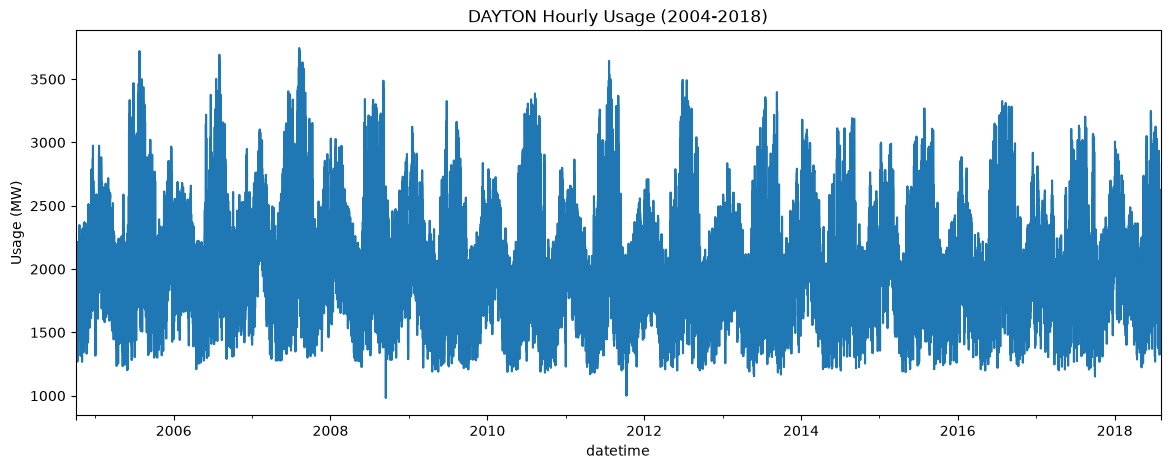

In [2]:
#Plotting Raw Series

df['usage_mw'].plot(title = 'DAYTON Hourly Usage (2004-2018)')
plt.ylabel('Usage (MW)')
plt.show()

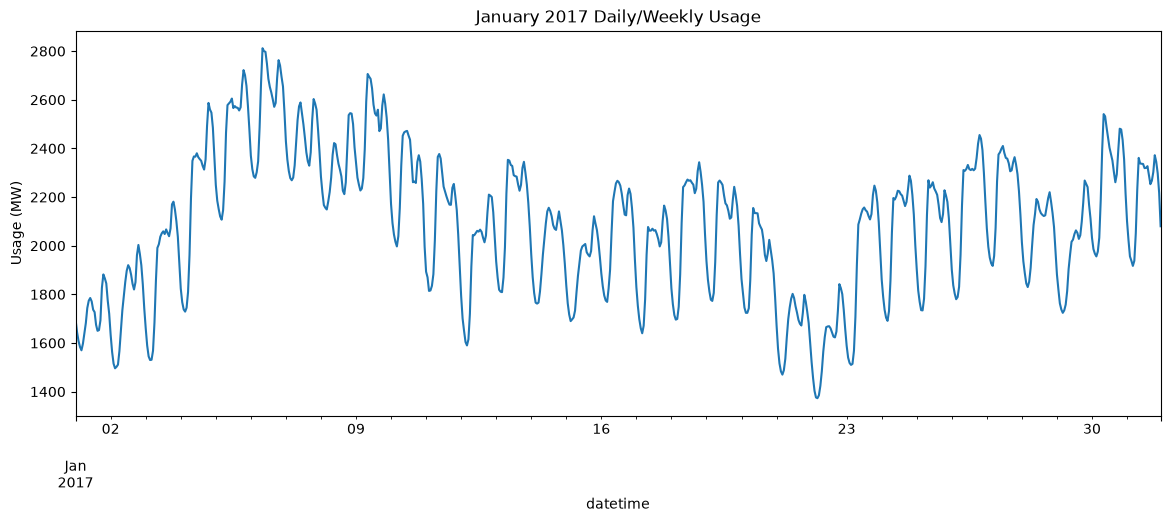

In [3]:
#Looking Closer for Patterns in Month

df.loc['2017-01-01':'2017-01-31', 'usage_mw'].plot(title = "January 2017 Daily/Weekly Usage")
plt.ylabel('Usage (MW)')
plt.show()

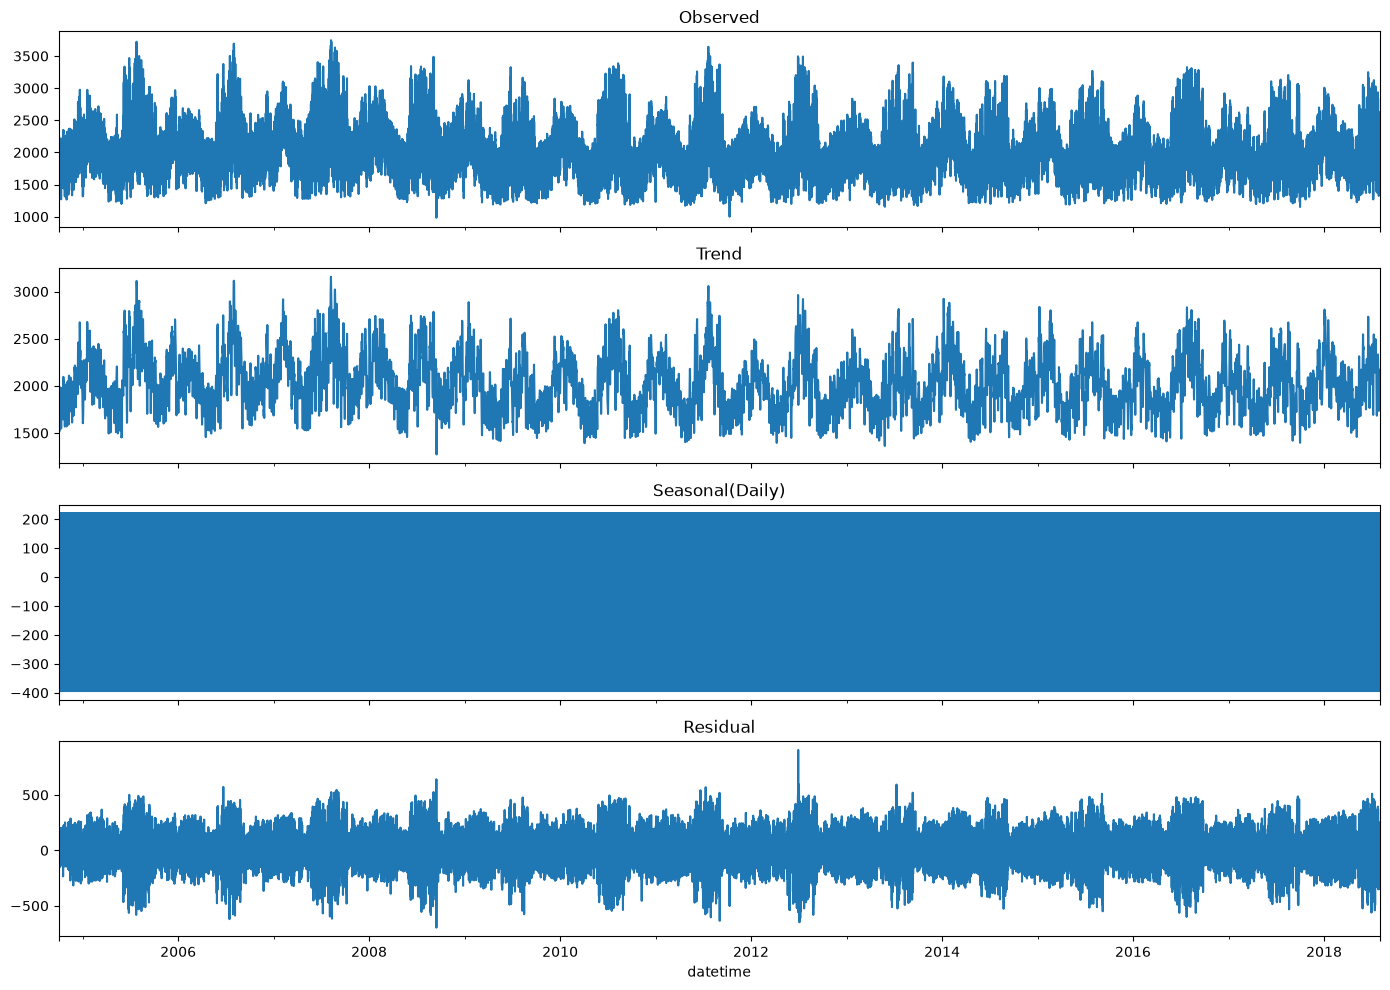

In [4]:
#Finding Seasonal Decomposition

decomposition = seasonal_decompose(df['usage_mw'], model = 'additive', period = 24)
fig, axes = plt.subplots(4, 1, figsize = (14, 10), sharex = True)
decomposition.observed.plot(ax = axes[0], title = 'Observed')
decomposition.trend.plot(ax = axes[1], title = 'Trend')
decomposition.seasonal.plot(ax = axes[2], title = 'Seasonal(Daily)')
decomposition.resid.plot(ax = axes[3], title = 'Residual')
plt.tight_layout()
plt.show()

In [5]:
#ADF and KPSS Tests

def stationarity_tests(series, name = 'series'):
    adf_result = adfuller(series.dropna())
    kpss_result = kpss(series.dropna(), regression = 'c', nlags = 'auto')

    print(f'--- {name} ---')
    print(f'ADF statistic: {adf_result[0]:.4f}, p-value: {adf_result[1]:.4f}')
    print(f'  -> {'Stationary' if adf_result[1] < 0.05 else 'Non-stationary'} (ADF)')
    print(f'KPSS statistic: {kpss_result[0]:.4f}, p-value: {kpss_result[1]:.4f}')
    print(f'  -> {'Non-stationary' if kpss_result[1] < 0.05 else 'Stationary'} (KPSS)')
    print()

stationarity_tests(df['usage_mw'], 'Raw Usage_mw')

stationarity_tests(df['usage_mw'].diff(), 'First Difference')

stationarity_tests(df['usage_mw'].diff(24), 'Seasonal Difference (24 hours)')

C:\Users\icsce\AppData\Local\Temp\ipykernel_9456\2516472336.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression = 'c', nlags = 'auto')


--- Raw Usage_mw ---
ADF statistic: -22.5373, p-value: 0.0000
  -> Stationary (ADF)
KPSS statistic: 3.1363, p-value: 0.0100
  -> Non-stationary (KPSS)



C:\Users\icsce\AppData\Local\Temp\ipykernel_9456\2516472336.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression = 'c', nlags = 'auto')


--- First Difference ---
ADF statistic: -45.7189, p-value: 0.0000
  -> Stationary (ADF)
KPSS statistic: 0.0098, p-value: 0.1000
  -> Stationary (KPSS)

--- Seasonal Difference (24 hours) ---
ADF statistic: -47.7260, p-value: 0.0000
  -> Stationary (ADF)
KPSS statistic: 0.0020, p-value: 0.1000
  -> Stationary (KPSS)



C:\Users\icsce\AppData\Local\Temp\ipykernel_9456\2516472336.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression = 'c', nlags = 'auto')


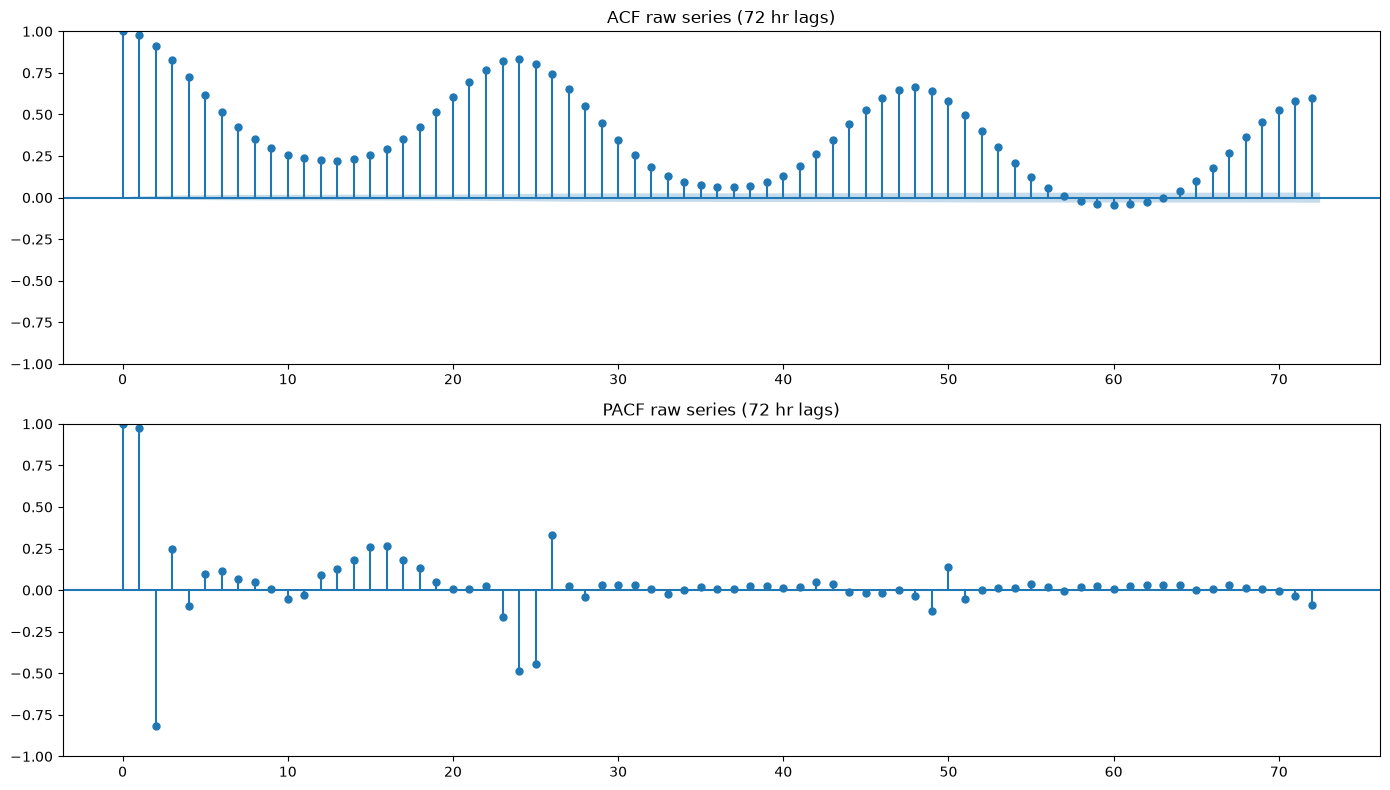

In [6]:
#Autocorrelation and PACF Plots

fig, axes = plt.subplots(2, 1, figsize = (14, 8))
plot_acf(df['usage_mw'].dropna(), lags = 72, ax = axes[0])
axes[0].set_title('ACF raw series (72 hr lags)')
plot_pacf(df['usage_mw'].dropna(), lags=72, ax=axes[1])
axes[1].set_title("PACF raw series (72 hr lags)")
plt.tight_layout()
plt.show()

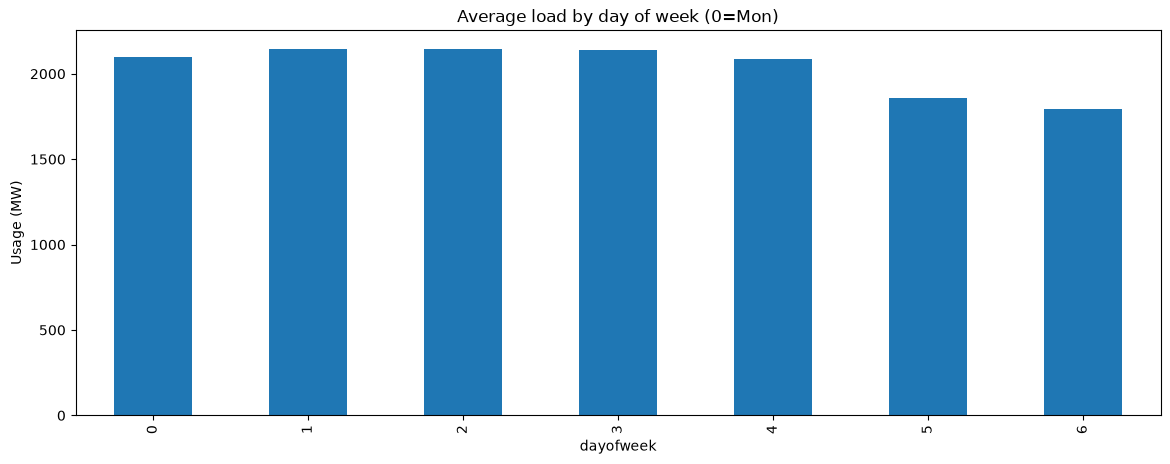

In [7]:
#Weekly Seasonality Analysis

df_by_dow = df.copy()
df_by_dow['dayofweek'] = df_by_dow.index.dayofweek
df_by_dow.groupby('dayofweek')['usage_mw'].mean().plot( kind='bar', title="Average load by day of week (0=Mon)")
plt.ylabel("Usage (MW)")
plt.show()

## Data Analysis Summary

- Raw Series: ADF test suggests that the series is stationary because of the low p-value (0.000). KPSS test suggests the opposite and says that the series is non-stationary because of the p-value 0.01. Main takeaway from this is the series could be a seasonally changing series as opposed to a series with only one stochastic trend. This would make sense because electricity demand varies from day-to-day and within the week (weekend vs. weekdayy). 
- First difference: stationary by both ADF and KPSS. 
- Seasonal Difference (lag 24): stationary by both tests however there is an even stronger ADF statistic (-47.7 vs. -45.7) than first-order differencing. This shows how dominant the daily seasonal structure is within the series. 

**Daily seasonality**
- ACF graph has a clear repeating wave pattern with peaks at lags 24, 48, 72. This is good evidence for a daily seasonal cycle. 

**Weekly seasonality**
- Weekday usage is fairly stable (2100 MW), dipping slightly Friday. There is a 
  clear 12-15% drop on weekends (1800 MW). So this pattern is present but not as significant as the daily cycle.

**Implications for modeling**
- SARIMA: use seasonal period m=24, with D=1 seasonal differencing. Starting 
  order to test: SARIMA(1,0,1)(1,1,1)[24]. This can be tuned to perfection via AIC/BIC comparison in a future update of the project.
- Since SARIMA cannot jointly model both daily and weekly seasonality, weekly 
  effects will be displayed via calendar features in XGBoost and longer lookback windows in the LSTM. This is the reason I'm comparing multiple 
  models rather than utilizing SARIMA alone.